In [1]:
# ============================================================
# SCHRITT 1: Pakete importieren
# ============================================================
import torch
import open_clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from tqdm import tqdm

print(f'CUDA verfügbar: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA verfügbar: True
GPU: Quadro T1000


In [3]:
# ============================================================
# SCHRITT 2: Pfade konfigurieren
# ============================================================
IMAGE_FOLDER = r'C:\Users\Lukas\masterthesis\thesis_2026\data\All_images'
OUTPUT_CSV   = r'C:\Users\Lukas\masterthesis\thesis_2026\data\indoor_outdoor_classification.csv'

SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

image_paths = [
    os.path.join(IMAGE_FOLDER, f)
    for f in os.listdir(IMAGE_FOLDER)
    if f.endswith(SUPPORTED_FORMATS)
]

print(f'✅ {len(image_paths)} Bilder gefunden')

✅ 11957 Bilder gefunden


In [4]:
# ============================================================
# SCHRITT 3: CLIP ViT-L/14 laden
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Verwende Gerät: {device}')

model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-L-14', pretrained='openai'
)
tokenizer = open_clip.get_tokenizer('ViT-L-14')
model = model.to(device)
model.eval()
print('✅ CLIP ViT-L/14 geladen')

Verwende Gerät: cuda


C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ CLIP ViT-L/14 geladen


In [17]:
# ============================================================
# SCHRITT 4: Kategorien definieren
# ============================================================
CATEGORIES = {
    'outdoor': (
        'a photo taken outside in the open air, showing sky, landscape, '
        'streets, building facades, exterior walls, trees, parks or nature'
    ),
    'indoor': (
        'a photo taken from inside a building, showing an interior room '
        'with ceiling overhead, indoor floor, interior walls with windows '
        'viewed from inside, furniture, lamps or indoor equipment'
    ),
}

category_names = list(CATEGORIES.keys())

with torch.no_grad():
    tokens = tokenizer(list(CATEGORIES.values())).to(device)
    text_features = model.encode_text(tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f'✅ Kategorien: {category_names}')
print()
for name, prompt in CATEGORIES.items():
    print(f'  {name}: {prompt}')

✅ Kategorien: ['human', 'non_human']

  human: a photo of one or more people posing, standing, walking or being photographed, where humans are the main subject or focal point of the image, such as portraits, selfies, group photos or tourist photos with people in the foreground
  non_human: a photo without people as the main subject, showing landscapes, ecosystems, vegetation, wildlife, mountains, rivers, lakes, glaciers, forests, grasslands, rocks, soil, buildings, roads, infrastructure or any other natural or human-made features where no person is the focal point


In [18]:
# ============================================================
# SCHRITT 5: Klassifikationsfunktion
# ============================================================
import shutil

def classify_image(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(image).unsqueeze(0).to(device)

        with torch.no_grad():
            img_features = model.encode_image(img_tensor)
            img_features = img_features / img_features.norm(dim=-1, keepdim=True)
            similarities = (img_features @ text_features.T).squeeze()
            # Original – ohne * 100
            probs = torch.softmax(similarities, dim=0).cpu().numpy()

        best_idx   = probs.argmax()
        category   = category_names[best_idx]
        confidence = probs[best_idx]

        return category, round(float(confidence), 4), None
    except Exception as e:
        return None, None, str(e)

print('✅ Klassifikationsfunktion definiert')

✅ Klassifikationsfunktion definiert


In [19]:
# ============================================================
# SCHRITT 5: Klassifikationsfunktion
# ============================================================
def classify_image(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(image).unsqueeze(0).to(device)

        with torch.no_grad():
            img_features = model.encode_image(img_tensor)
            img_features = img_features / img_features.norm(dim=-1, keepdim=True)
            similarities = (img_features @ text_features.T).squeeze()
            probs = torch.softmax(similarities, dim=0).cpu().numpy()

        best_idx   = probs.argmax()
        category   = category_names[best_idx]
        confidence = probs[best_idx]

        return category, round(float(confidence), 4), None
    except Exception as e:
        return None, None, str(e)

print('✅ Klassifikationsfunktion definiert')

✅ Klassifikationsfunktion definiert


Testbild:   image_1.jpg
Kategorie:  non_human
Konfidenz:  0.5092


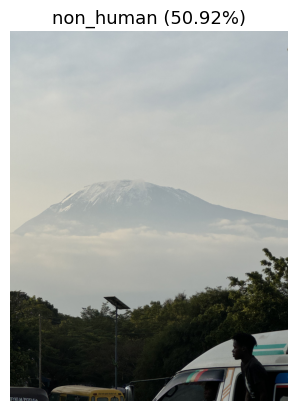

In [20]:
# ============================================================
# SCHRITT 6: Schnelltest mit einem Bild
# ============================================================
test_path = image_paths[0]
category, confidence, error = classify_image(test_path)

print(f'Testbild:   {os.path.basename(test_path)}')
print(f'Kategorie:  {category}')
print(f'Konfidenz:  {confidence}')

img = Image.open(test_path).convert('RGB')
plt.imshow(img)
plt.title(f'{category} ({confidence:.2%})', fontsize=13)
plt.axis('off')
plt.show()

In [21]:
# ============================================================
# SCHRITT 7: Alle Bilder klassifizieren
# ============================================================
results = []
errors  = []

print(f'Klassifiziere {len(image_paths)} Bilder...')

for img_path in tqdm(image_paths):
    filename = os.path.basename(img_path)
    category, confidence, error = classify_image(img_path)

    if error:
        errors.append({'filename': filename, 'error': error})
    else:
        results.append({
            'filename':   filename,
            'filepath':   img_path,
            'category':   category,
            'confidence': confidence,
        })

print(f'\n✅ {len(results)} Bilder klassifiziert')
print(f'⚠️  {len(errors)} Fehler')

Klassifiziere 11957 Bilder...


100%|████████████████████████████████████████████████████████████████████████████| 11957/11957 [46:05<00:00,  4.32it/s]


✅ 11957 Bilder klassifiziert
⚠️  0 Fehler


In [22]:
df = pd.DataFrame(results)

print('=== Ergebnisse ===')
print(f'outdoor: {(df["category"] == "outdoor").sum()} Bilder')
print(f'indoor:  {(df["category"] == "indoor").sum()} Bilder')
print()
print(f'Ø Konfidenz outdoor: {df[df["category"]=="outdoor"]["confidence"].mean():.4f}')
print(f'Ø Konfidenz indoor:  {df[df["category"]=="indoor"]["confidence"].mean():.4f}')

df.to_csv(OUTPUT_CSV, index=False)
print(f'\n✅ CSV gespeichert: {OUTPUT_CSV}')

=== Ergebnisse ===
non_human: 7356 Bilder
human:  4601 Bilder

Ø Konfidenz non_human: 0.5068
Ø Konfidenz human:  0.5057

✅ CSV gespeichert: C:\Users\Lukas\masterthesis\thesis_2026\data\human_nature_classification.csv


In [24]:
SORT_OUTPUT = r'C:\Users\Lukas\masterthesis\thesis_2026\data\all_images_sorted'

sorted_dirs = {
    'outdoor': os.path.join(SORT_OUTPUT, 'outdoor'),
    'indoor':  os.path.join(SORT_OUTPUT, 'indoor')
}

for d in sorted_dirs.values():
    os.makedirs(d, exist_ok=True)

print('Sortiere Bilder...')
for _, row in df.iterrows():
    shutil.copy(row['filepath'], sorted_dirs[row['category']])

print(f'✅ Bilder sortiert:')
print(f'   indoor: {(df["category"] == "indoor").sum()} → {sorted_dirs["indoor"]}')
print(f'   outdoor:  {(df["category"] == "outdoor").sum()} → {sorted_dirs["outdoor"]}')

Sortiere Bilder...
✅ Bilder sortiert:
   human: 4601 → C:\Users\Lukas\masterthesis\thesis_2026\data\all_images_sorted\human
   non_human:  7356 → C:\Users\Lukas\masterthesis\thesis_2026\data\all_images_sorted\non_human


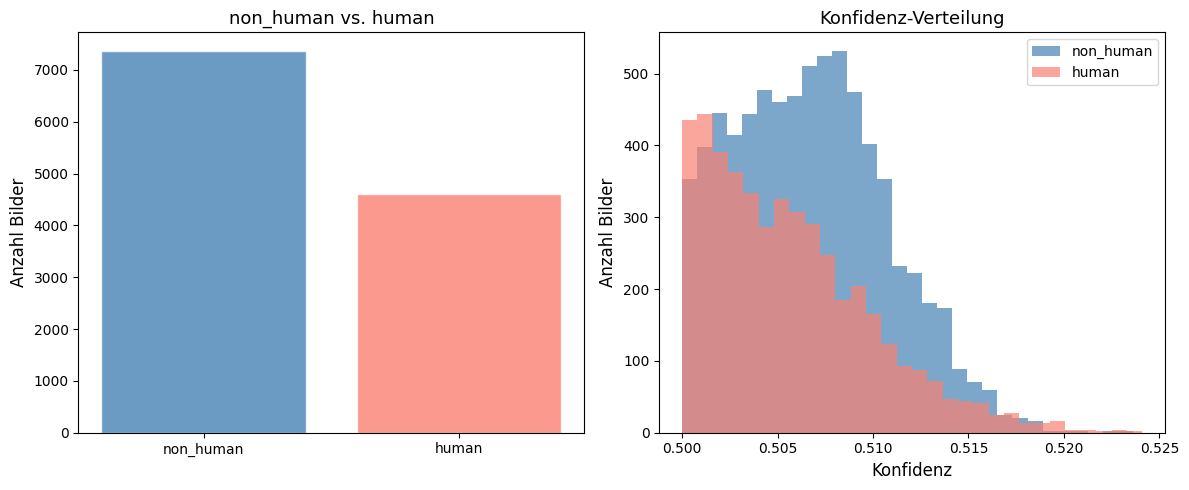

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['category'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['steelblue', 'salmon'], edgecolor='white', alpha=0.8)
axes[0].set_ylabel('Anzahl Bilder', fontsize=12)
axes[0].set_title('outdoor vs. indoor', fontsize=13)

axes[1].hist(df[df['category']=='outdoor']['confidence'],
             bins=30, alpha=0.7, color='steelblue', label='outdoor')
axes[1].hist(df[df['category']=='indoor']['confidence'],
             bins=30, alpha=0.7, color='salmon', label='indoor')
axes[1].set_xlabel('Konfidenz', fontsize=12)
axes[1].set_ylabel('Anzahl Bilder', fontsize=12)
axes[1].set_title('Konfidenz-Verteilung', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()